In [32]:
import numpy as np
import cellrank as cr
import scanpy as sc
import scvelo as scv

import json
from datetime import datetime

In [34]:
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')

In [2]:
adata = sc.read_h5ad('data/gut_data/gut_hs_fetal_epithelial_scVI_AM_06032025_145649_raw.h5ad')

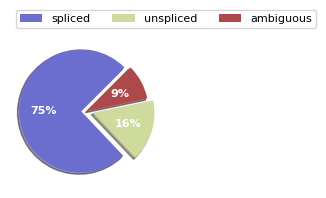

In [3]:
scv.pl.proportions(adata)

In [4]:
scv.pp.filter_and_normalize(
    adata, min_shared_counts=20, n_top_genes=2000, subset_highly_variable=False
)

Filtered out 28191 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.


/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


Logarithmized X.


In [5]:
sc.tl.pca(adata)
sc.pp.neighbors(adata, n_pcs=30, n_neighbors=30, random_state=0)
scv.pp.moments(adata, n_pcs=None, n_neighbors=None)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


computing moments based on connectivities
    finished (0:01:03) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


## Run scVelo

In [6]:
scv.tl.recover_dynamics(adata, n_jobs=8)

recovering dynamics (using 8/8 cores)
or disable the progress bar using `show_progress_bar=False`.
    finished (0:35:19) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)


In [7]:
scv.tl.velocity(adata, mode="dynamical")

computing velocities
    finished (0:01:26) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


## Set up the VelocityKernel

In [8]:
vk = cr.kernels.VelocityKernel(adata)

In [9]:
vk.compute_transition_matrix()

  0%|                                                                                                                                                                               | 0/71712 [00:00<?, ?cell/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 71712/71712 [00:12<00:00, 5558.04cell/s]


VelocityKernel[n=71712, model='deterministic', similarity='correlation', softmax_scale=2.496]

## Combine with gene expression similarity

In [10]:
ck = cr.kernels.ConnectivityKernel(adata)
ck.compute_transition_matrix()

combined_kernel = 0.8 * vk + 0.2 * ck

## Visualize the transition matrix

In [11]:
adata.obs['cell_states'] = adata.obs['cell_states'].astype('str') + '_' + adata.obs['leiden_cluster'].astype('str')

In [20]:
adata.obs['cell_states'] = adata.obs['cell_states'].str.replace(r'_nan', '', regex=True)

In [13]:
adata.obs['cell_states'] = adata.obs['cell_states'].astype('category')

/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is d

saving figure to file /Users/annamaguza/Desktop/Repos/Fetal_stem_cells_analysis/2_trajectory_analysis/figures/RNA_velocity_umap_transition_matrix.png


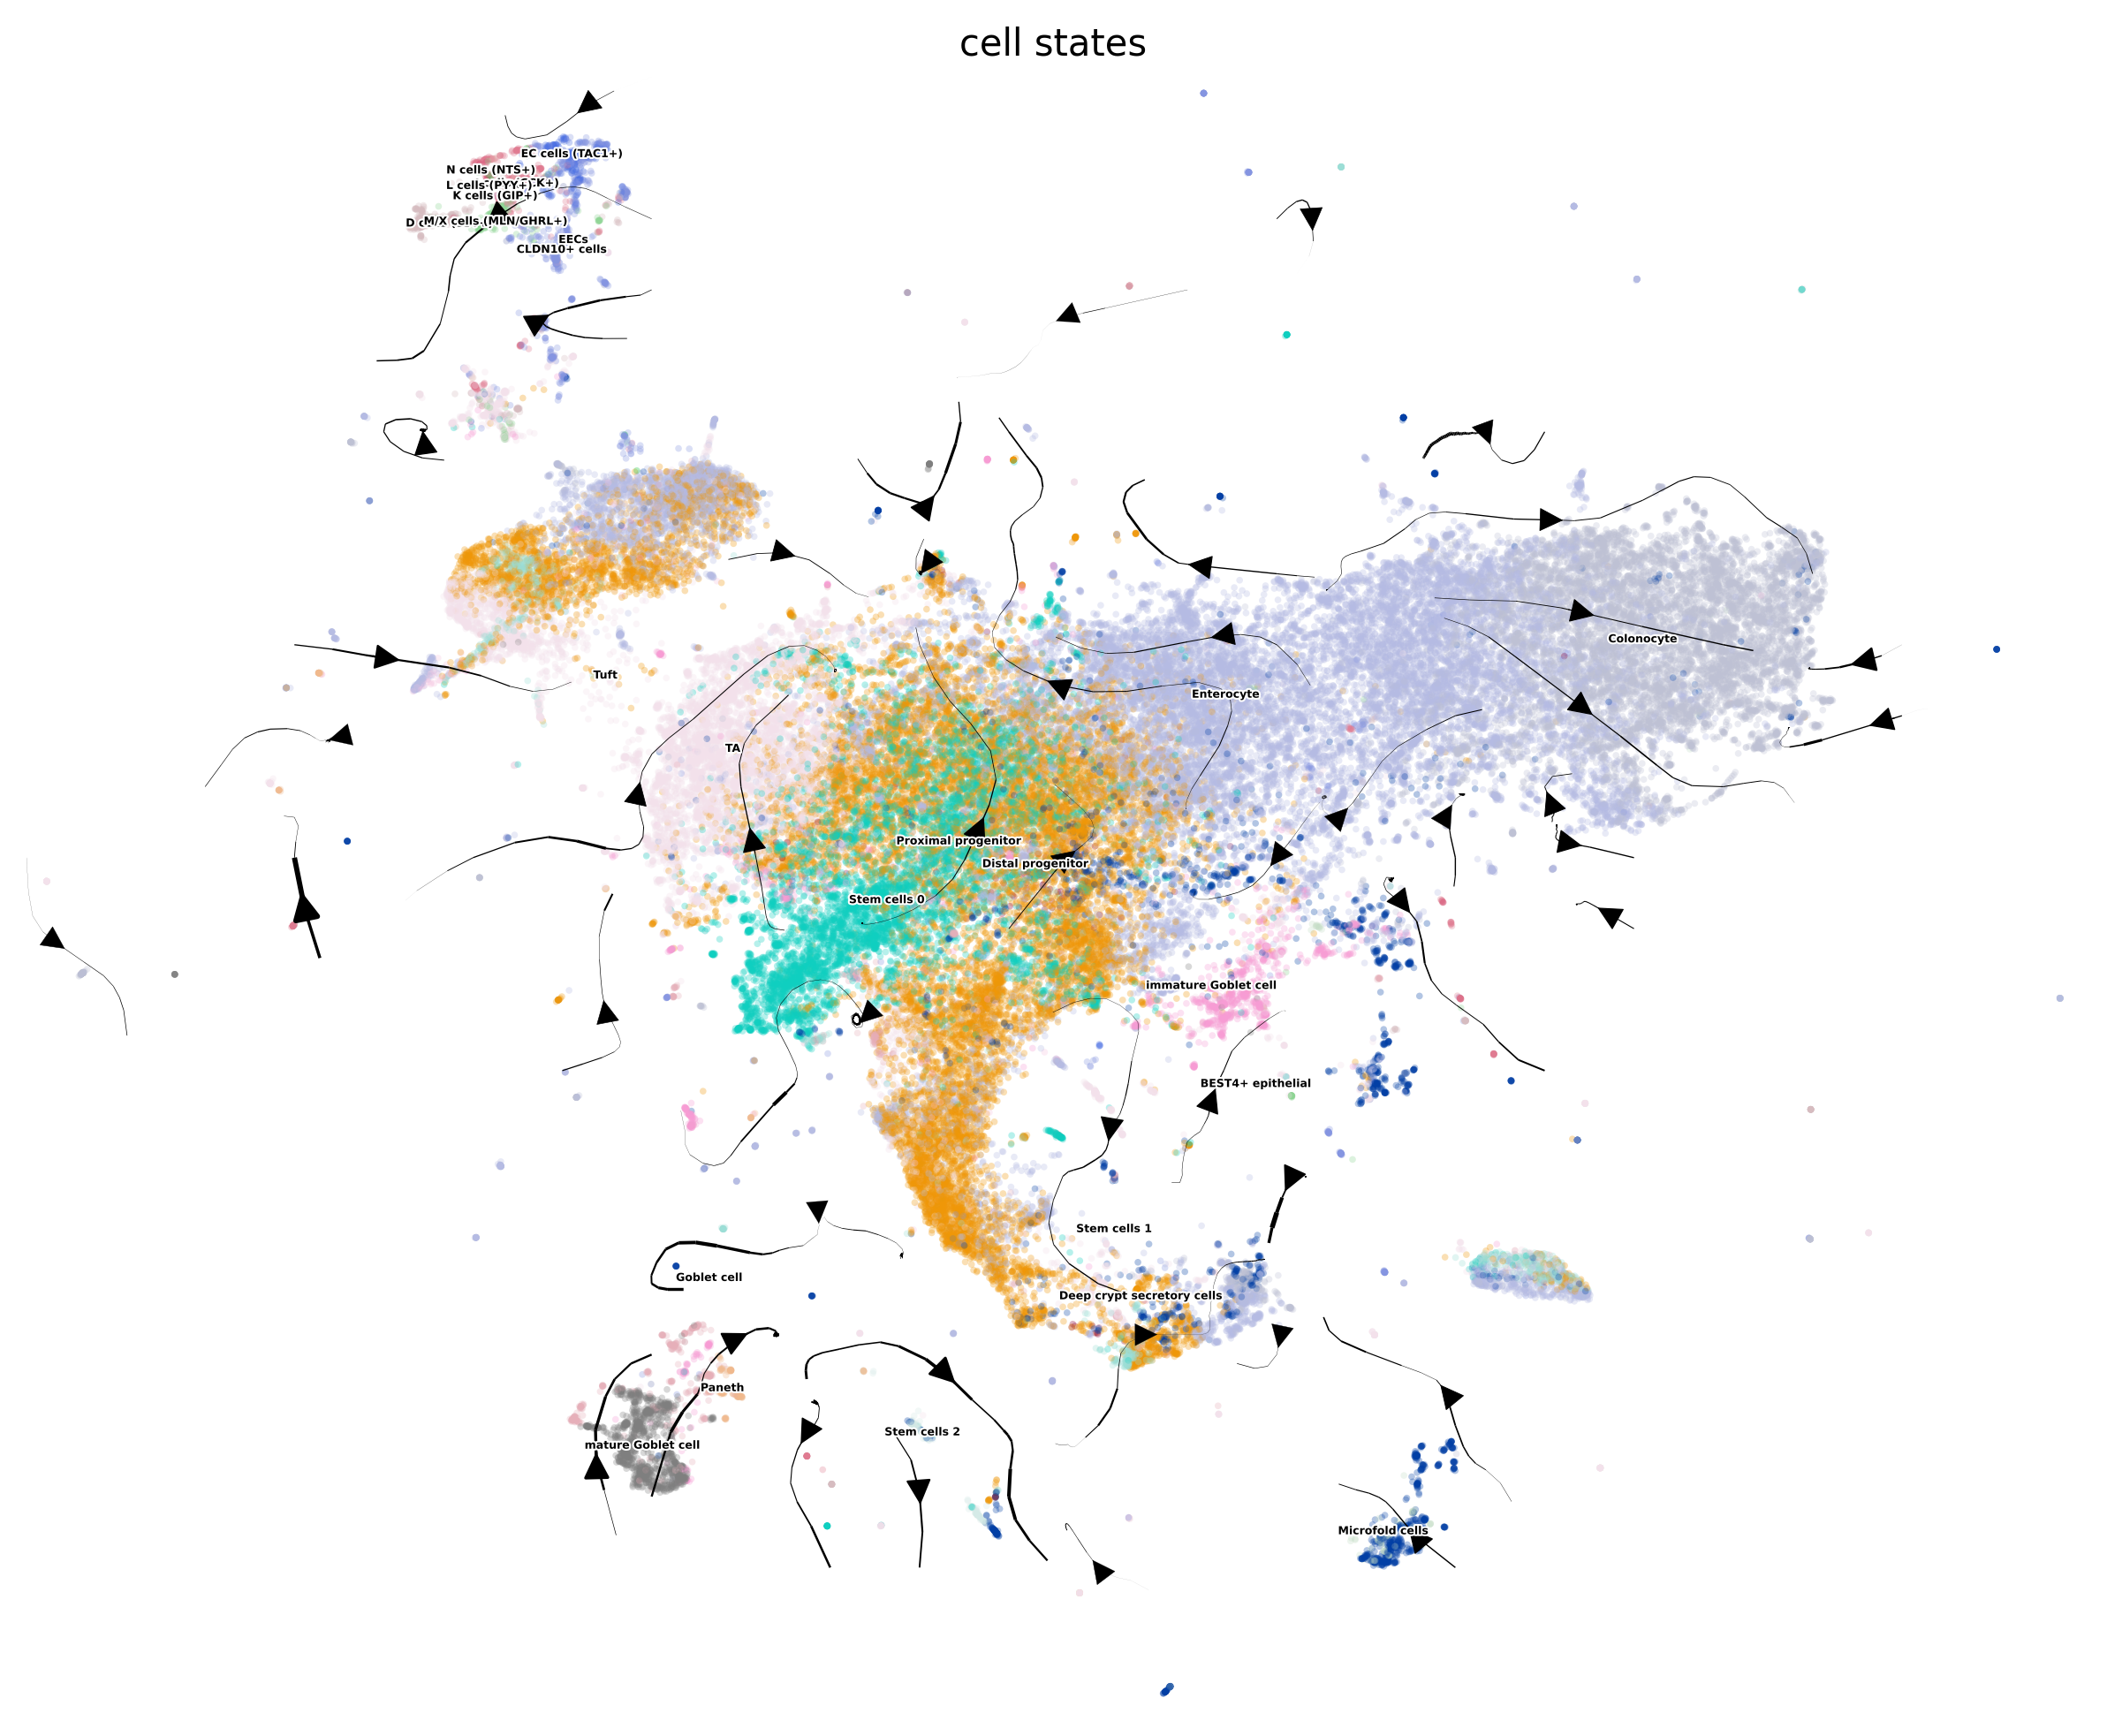

In [14]:
vk.plot_projection(
    basis='X_umap',           
    color='cell_states',     
    arrow_size=1.5,      
    density=0.8,         
    figsize=(10, 8),
    legend_loc='on data',
    legend_fontsize=3,
    save="figures/RNA_velocity_umap_transition_matrix.png",
    dpi= 300
)

In [16]:
vk.plot_random_walks(
    start_ixs={"cell_states": "Stem cells_0"},  # Starting point
    max_iter=10,
    seed=0,
    color='cell_states',            
    basis='X_umap',                 # Projection to use
    legend_loc='right margin',    # Legend position
    figsize=(10, 8),              # Figure size
    show_progress_bar=False,
    save="figures/RNA_velocity_umap_SC0_random_walk.png",
    dpi= 300
)

In [17]:
vk.plot_random_walks(
    start_ixs={"cell_states": "Stem cells_1"},  # Starting point
    max_iter=10,
    seed=0,
    color='cell_states',            
    basis='X_umap',                 # Projection to use
    legend_loc='right margin',    # Legend position
    figsize=(10, 8),              # Figure size
    show_progress_bar=False,
    save="figures/RNA_velocity_umap_SC1_random_walk.png",
    dpi= 300
)

In [18]:
vk.plot_random_walks(
    start_ixs={"cell_states": "Stem cells_2"},  # Starting point
    max_iter=10,
    seed=0,
    color='cell_states',            
    basis='X_umap',                 # Projection to use
    legend_loc='right margin',    # Legend position
    figsize=(10, 8),              # Figure size
    show_progress_bar=False,
    save="figures/RNA_velocity_umap_SC2_random_walk.png",
    dpi= 300
)

In [25]:
adata.obs["cell_states"] = adata.obs["cell_states"].astype("category")

In [ ]:
vk.plot_random_walks(
    start_ixs={"cell_states": "Distal progenitor"},  # Starting point
    max_iter=10,
    seed=0,
    color='cell_states',            
    basis='X_umap',                 # Projection to use
    legend_loc='right margin',    # Legend position
    figsize=(10, 8),              # Figure size
    show_progress_bar=False,
    save="figures/RNA_velocity_umap_Distal_progenitor_random_walk.png",
    dpi= 300
)

In [ ]:
vk.plot_random_walks(
    start_ixs={"cell_states": "Proximal progenitor"},  # Starting point
    max_iter=10,
    seed=0,
    color='cell_states',            
    basis='X_umap',                 # Projection to use
    legend_loc='right margin',    # Legend position
    figsize=(10, 8),              # Figure size
    show_progress_bar=False,
    save="figures/RNA_velocity_umap_Proximal_progenitor_random_walk.png",
    dpi= 300
)

In [ ]:
vk.plot_random_walks(
    start_ixs={"cell_states": "TA_"},  # Starting point
    max_iter=10,
    seed=0,
    color='cell_states',            
    basis='X_umap',                 # Projection to use
    legend_loc='right margin',    # Legend position
    figsize=(10, 8),              # Figure size
    show_progress_bar=False,
    save="figures/RNA_velocity_umap_TA_random_walk.png",
    dpi= 300
)

In [30]:
vk.write_to_adata()

In [35]:
current_history = adata.uns['processing_history'].tolist()

new_entry = json.dumps({
    'timestamp': timestamp,
    'step': 'Run RNA velocity analysis with cell rank',
})
current_history.append(new_entry)

adata.uns['processing_history'] = current_history

In [37]:
project = 'gut'
species = 'hs'
name = 'AM'
counts = 'raw'
atribute = 'fetal_epithelial_RNA_velocity'

adata.write_h5ad(f"data/gut_data/{project}_{species}_{atribute}_{name}_{timestamp}_{counts}.h5ad")

## Computing Initial and Terminal States

In [ ]:
g = cr.estimators.GPCCA(vk)
print(g)

In [ ]:
g.fit(cluster_key="cell_states", n_states=[4, 12])

In [ ]:
g.plot_macrostates(which="all", discrete=True, legend_loc="right", s=100)

In [ ]:
g.predict_terminal_states()

In [ ]:
g.plot_macrostates(which="terminal", legend_loc="right", s=100)

In [ ]:
g.plot_macrostates(which="terminal", discrete=False)

In [ ]:
g.predict_initial_states()

In [ ]:
g.plot_macrostates(which="initial", legend_loc="right", s=100)

In [ ]:
g

In [16]:
cr.logging.print_versions()

cellrank==2.0.6 scanpy==1.10.4 anndata==0.11.3 numpy==1.26.4 numba==0.61.0 scipy==1.11.4 pandas==2.2.3 pygpcca==1.0.4 scikit-learn==1.6.1 statsmodels==0.14.4 python-igraph==0.11.8 scvelo==0.3.3 pygam==0.9.1 matplotlib==3.10.0 seaborn==0.13.2
